In [1]:
# === 📊 HULL TACTICAL - EXPLORATORY DATA ANALYSIS (EDA) ===
# Comprehensive analysis of market data for the Hull Tactical Market Prediction competition

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

# Load data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Sort by date
train = train.sort_values("date_id").reset_index(drop=True)

print("="*70)
print(" HULL TACTICAL - EXPLORATORY DATA ANALYSIS")
print("="*70)
print(f"\nTrain shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Date range:  {train['date_id'].min()} to {train['date_id'].max()}")
print(f"Years (approx): {(train['date_id'].max() - train['date_id'].min()) / 252:.1f}")

train.head()

 HULL TACTICAL - EXPLORATORY DATA ANALYSIS

Train shape: (9048, 98)
Test shape:  (10, 99)
Date range:  0 to 9047
Years (approx): 35.9


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301



 1. RETURNS DISTRIBUTION & STATISTICAL PROPERTIES



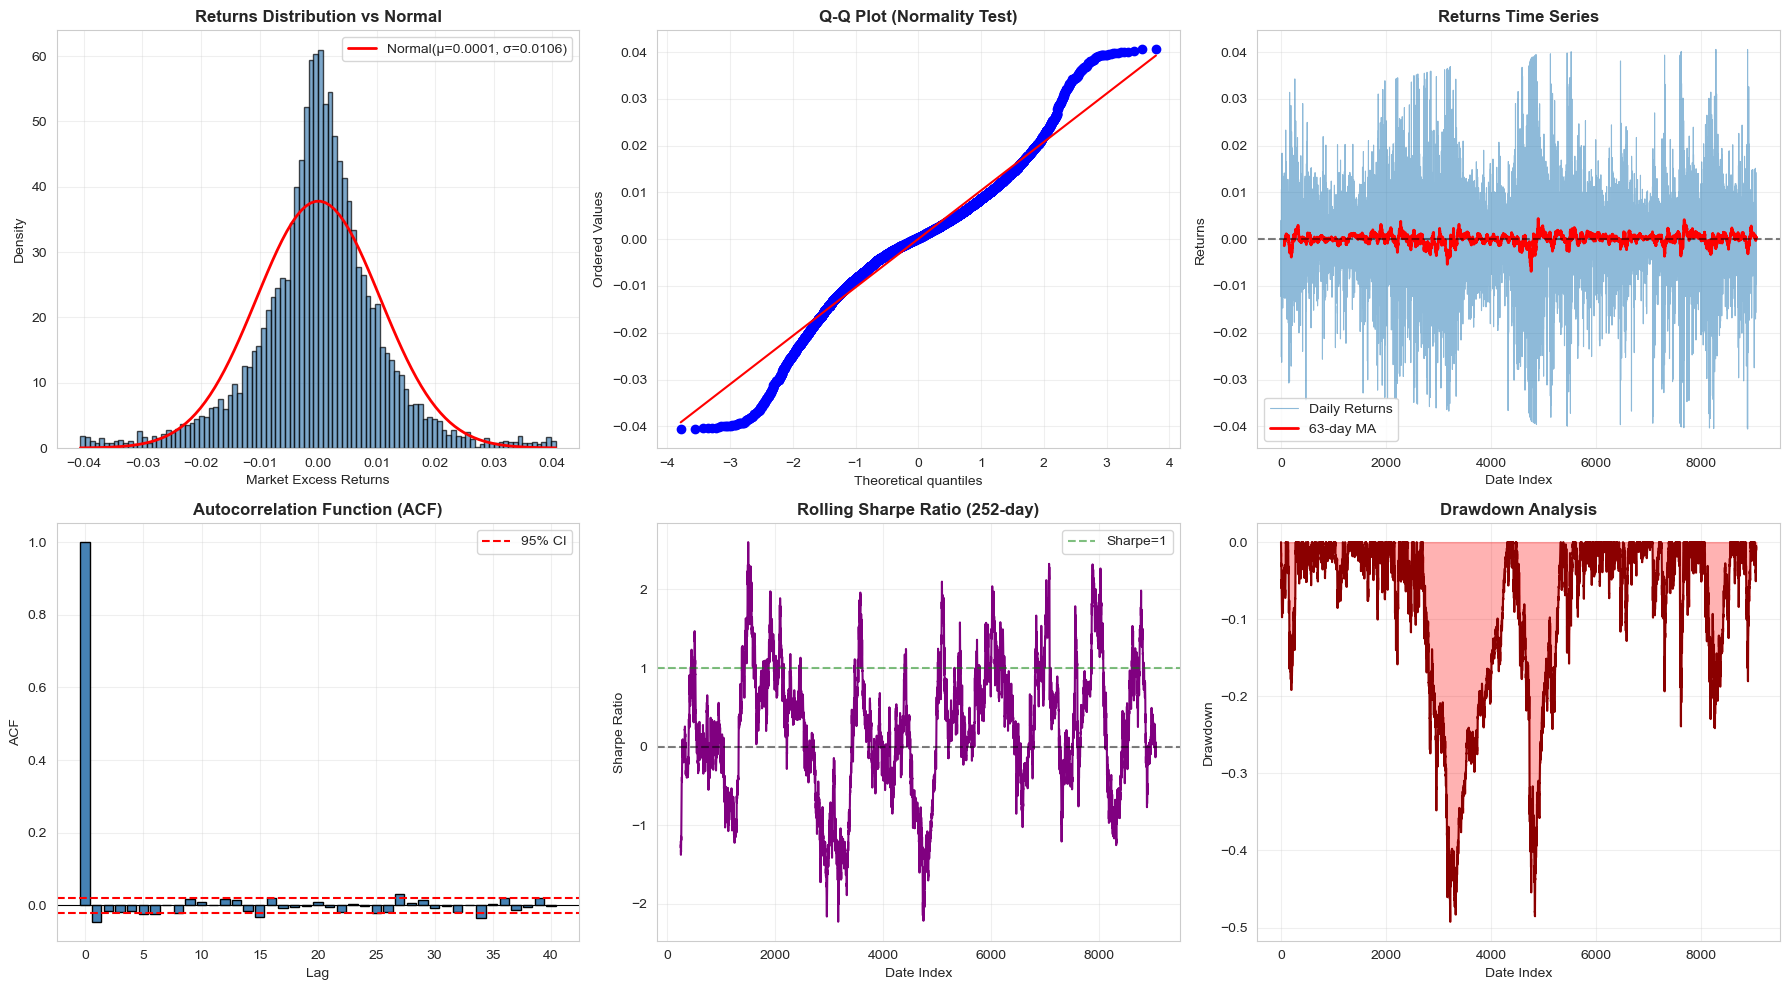


📊 Statistical Summary:
   Mean:        0.000052
   Std Dev:     0.010552
   Skewness:    -0.1800
   Kurtosis:    2.2445
   Min:         -0.040582
   Max:         0.040551

📈 Normality Tests:
   Shapiro-Wilk: stat=0.9609, p-value=0.0000
   ✗ NOT Normal (α=0.05)

📉 Stationarity Test (Augmented Dickey-Fuller):
   ADF Statistic: -17.5705
   p-value:       0.0000
   ✓ Stationary (α=0.05)
   Critical values: {'1%': -3.431075667094735, '5%': -2.8618606978263332, '10%': -2.5669407024213844}

💰 Annualized Metrics:
   Return:      1.30%
   Volatility:  16.75%
   Sharpe:      0.0776
   Max DD:      -49.24%


In [2]:
# === 1. RETURNS ANALYSIS ===
print("\n" + "="*70)
print(" 1. RETURNS DISTRIBUTION & STATISTICAL PROPERTIES")
print("="*70 + "\n")

target = train["market_forward_excess_returns"]
fwd_ret = train["forward_returns"]

# Distribution analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1.1 Histogram with normal overlay
axes[0, 0].hist(target.dropna(), bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='black')
mu, sigma = target.mean(), target.std()
x = np.linspace(target.min(), target.max(), 100)
axes[0, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Normal(μ={mu:.4f}, σ={sigma:.4f})')
axes[0, 0].set_title('Returns Distribution vs Normal', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Market Excess Returns')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 1.2 Q-Q Plot
stats.probplot(target.dropna(), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Test)', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 1.3 Time series with rolling mean
axes[0, 2].plot(target.values, alpha=0.5, label='Daily Returns', linewidth=0.8)
axes[0, 2].plot(target.rolling(63).mean().values, color='red', linewidth=2, label='63-day MA')
axes[0, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 2].set_title('Returns Time Series', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Date Index')
axes[0, 2].set_ylabel('Returns')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 1.4 Autocorrelation (ACF)
acf_vals = acf(target.dropna(), nlags=40)
axes[1, 0].bar(range(len(acf_vals)), acf_vals, width=0.8, color='steelblue', edgecolor='black')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].axhline(y=1.96/np.sqrt(len(target)), color='red', linestyle='--', label='95% CI')
axes[1, 0].axhline(y=-1.96/np.sqrt(len(target)), color='red', linestyle='--')
axes[1, 0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].set_ylabel('ACF')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 1.5 Rolling Sharpe (252-day)
rolling_sharpe = (target.rolling(252).mean() / target.rolling(252).std()) * np.sqrt(252)
axes[1, 1].plot(rolling_sharpe.values, color='purple', linewidth=1.5)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].axhline(y=1, color='green', linestyle='--', alpha=0.5, label='Sharpe=1')
axes[1, 1].set_title('Rolling Sharpe Ratio (252-day)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date Index')
axes[1, 1].set_ylabel('Sharpe Ratio')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 1.6 Drawdown analysis
cumulative = (1 + fwd_ret).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max
axes[1, 2].fill_between(range(len(drawdown)), drawdown.values, 0, alpha=0.3, color='red')
axes[1, 2].plot(drawdown.values, color='darkred', linewidth=1.5)
axes[1, 2].set_title('Drawdown Analysis', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Date Index')
axes[1, 2].set_ylabel('Drawdown')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("\n📊 Statistical Summary:")
print(f"   Mean:        {target.mean():.6f}")
print(f"   Std Dev:     {target.std():.6f}")
print(f"   Skewness:    {target.skew():.4f}")
print(f"   Kurtosis:    {target.kurtosis():.4f}")
print(f"   Min:         {target.min():.6f}")
print(f"   Max:         {target.max():.6f}")

# Normality tests
shapiro_stat, shapiro_p = stats.shapiro(target.dropna().sample(min(5000, len(target.dropna()))))
print(f"\n📈 Normality Tests:")
print(f"   Shapiro-Wilk: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print(f"   {'✗ NOT Normal' if shapiro_p < 0.05 else '✓ Normal'} (α=0.05)")

# Stationarity test (ADF)
adf_result = adfuller(target.dropna())
print(f"\n📉 Stationarity Test (Augmented Dickey-Fuller):")
print(f"   ADF Statistic: {adf_result[0]:.4f}")
print(f"   p-value:       {adf_result[1]:.4f}")
print(f"   {'✓ Stationary' if adf_result[1] < 0.05 else '✗ NOT Stationary'} (α=0.05)")
print(f"   Critical values: {adf_result[4]}")

# Annualized metrics
annual_return = target.mean() * 252
annual_vol = target.std() * np.sqrt(252)
sharpe = annual_return / annual_vol if annual_vol > 0 else 0
print(f"\n💰 Annualized Metrics:")
print(f"   Return:      {annual_return*100:.2f}%")
print(f"   Volatility:  {annual_vol*100:.2f}%")
print(f"   Sharpe:      {sharpe:.4f}")
print(f"   Max DD:      {drawdown.min()*100:.2f}%")


 2. VOLATILITY REGIMES & CLUSTERING



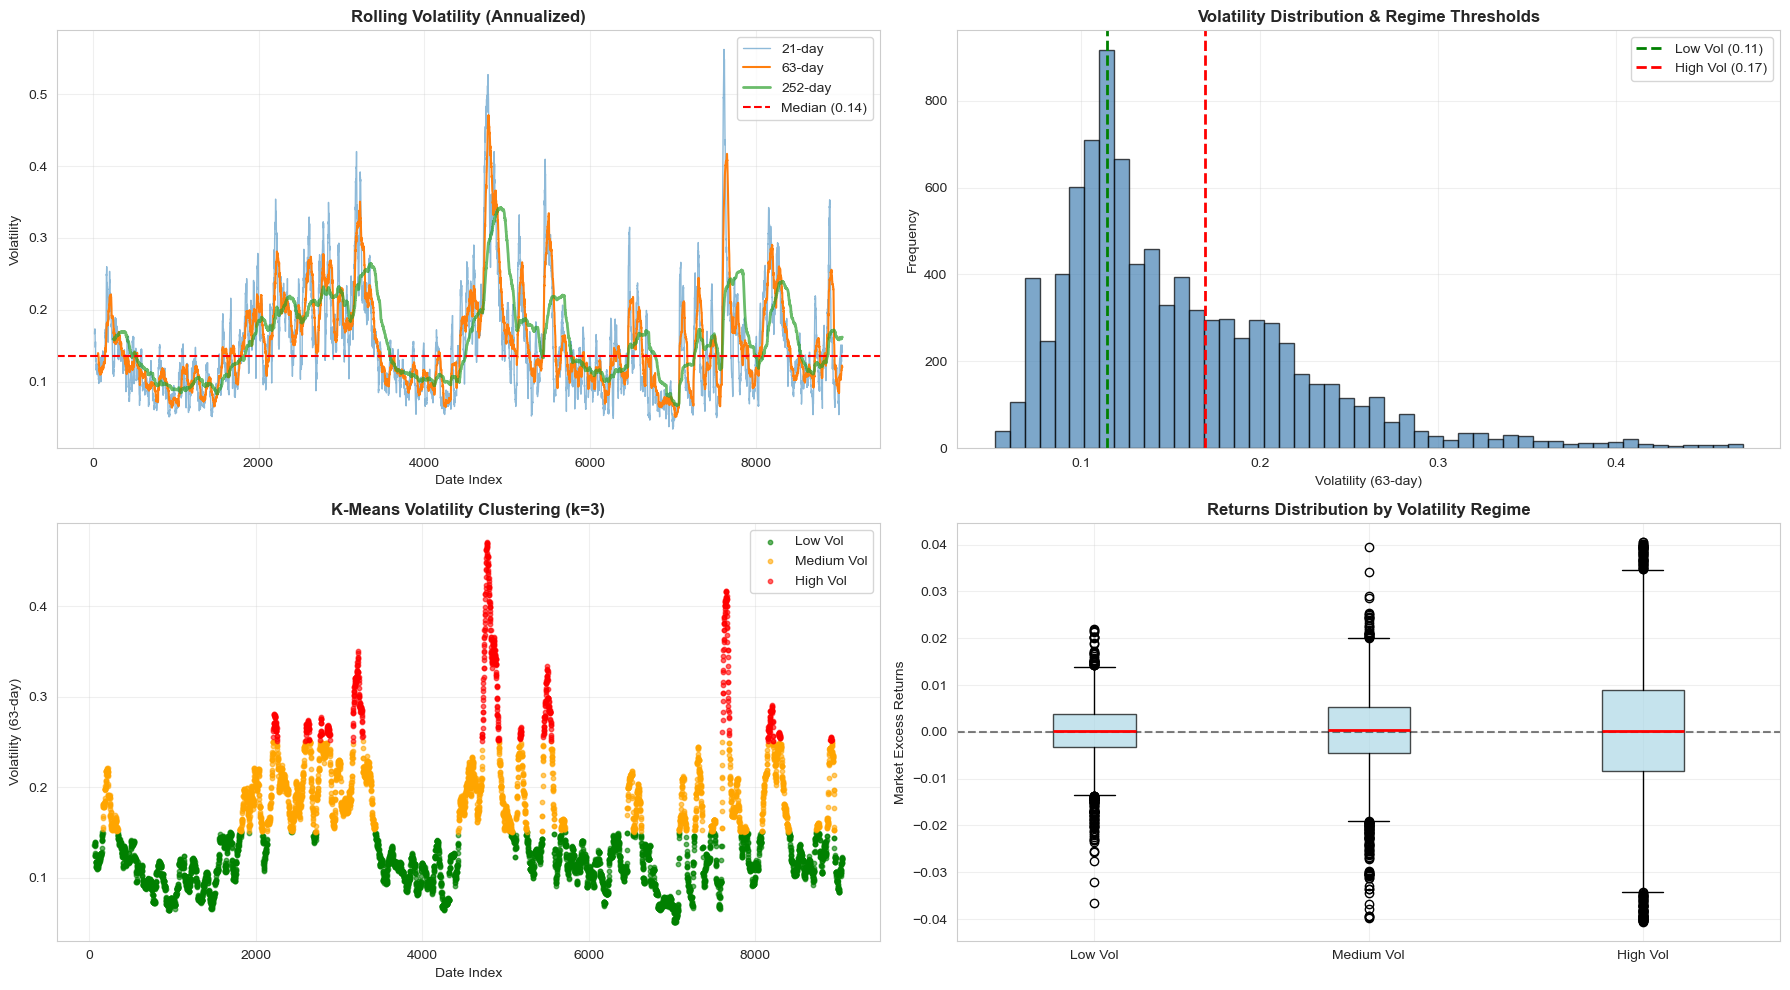


📊 Volatility Regime Statistics:

   Low Vol:
      Count:       2966
      Mean Return: 1.40% (annualized)
      Std Dev:     9.94% (annualized)
      Sharpe:      0.1406
      Min:         -0.036631
      Max:         0.021918

   Medium Vol:
      Count:       3054
      Mean Return: 2.18% (annualized)
      Std Dev:     14.17% (annualized)
      Sharpe:      0.1541
      Min:         -0.039775
      Max:         0.039610

   High Vol:
      Count:       2966
      Mean Return: 1.04% (annualized)
      Std Dev:     23.38% (annualized)
      Sharpe:      0.0443
      Min:         -0.040582
      Max:         0.040551


In [3]:
# === 2. VOLATILITY ANALYSIS & REGIME DETECTION ===
print("\n" + "="*70)
print(" 2. VOLATILITY REGIMES & CLUSTERING")
print("="*70 + "\n")

# Calculate rolling volatility
vol_21 = train["forward_returns"].rolling(21).std() * np.sqrt(252)
vol_63 = train["forward_returns"].rolling(63).std() * np.sqrt(252)
vol_252 = train["forward_returns"].rolling(252).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 2.1 Rolling volatility over time
axes[0, 0].plot(vol_21.values, alpha=0.5, label='21-day', linewidth=1)
axes[0, 0].plot(vol_63.values, label='63-day', linewidth=1.5)
axes[0, 0].plot(vol_252.values, alpha=0.7, label='252-day', linewidth=2)
axes[0, 0].axhline(y=vol_63.median(), color='red', linestyle='--', label=f'Median ({vol_63.median():.2f})')
axes[0, 0].set_title('Rolling Volatility (Annualized)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date Index')
axes[0, 0].set_ylabel('Volatility')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2.2 Volatility distribution & regimes
vol_data = vol_63.dropna()
low_vol_thresh = vol_data.quantile(0.33)
high_vol_thresh = vol_data.quantile(0.67)

axes[0, 1].hist(vol_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=low_vol_thresh, color='green', linestyle='--', linewidth=2, label=f'Low Vol ({low_vol_thresh:.2f})')
axes[0, 1].axvline(x=high_vol_thresh, color='red', linestyle='--', linewidth=2, label=f'High Vol ({high_vol_thresh:.2f})')
axes[0, 1].set_title('Volatility Distribution & Regime Thresholds', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Volatility (63-day)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 2.3 K-Means clustering on volatility
vol_for_cluster = vol_63.dropna().values.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(vol_for_cluster)

# Map to full index
cluster_series = pd.Series(index=train.index, dtype=float)
cluster_series.loc[vol_63.dropna().index] = clusters

colors_map = {0: 'green', 1: 'orange', 2: 'red'}
cluster_names = {0: 'Low Vol', 1: 'Medium Vol', 2: 'High Vol'}

# Sort clusters by centroid value
centroids_sorted = sorted(enumerate(kmeans.cluster_centers_.flatten()), key=lambda x: x[1])
old_to_new = {old_idx: new_idx for new_idx, (old_idx, _) in enumerate(centroids_sorted)}
clusters_remapped = np.array([old_to_new[c] for c in clusters])

for i in range(3):
    mask = clusters_remapped == i
    indices = vol_63.dropna().index[mask]
    axes[1, 0].scatter(indices, vol_data.loc[indices], c=list(colors_map.values())[i], 
                       label=list(cluster_names.values())[i], alpha=0.6, s=10)
axes[1, 0].set_title('K-Means Volatility Clustering (k=3)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date Index')
axes[1, 0].set_ylabel('Volatility (63-day)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 2.4 Returns by volatility regime
regime_labels = pd.cut(vol_63, bins=[0, low_vol_thresh, high_vol_thresh, np.inf], 
                       labels=['Low Vol', 'Medium Vol', 'High Vol'])
returns_by_regime = train.groupby(regime_labels)["market_forward_excess_returns"].apply(list)

regime_data = [returns_by_regime['Low Vol'], returns_by_regime['Medium Vol'], returns_by_regime['High Vol']]
axes[1, 1].boxplot(regime_data, labels=['Low Vol', 'Medium Vol', 'High Vol'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Returns Distribution by Volatility Regime', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Market Excess Returns')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print regime statistics
print("\n📊 Volatility Regime Statistics:")
for regime in ['Low Vol', 'Medium Vol', 'High Vol']:
    data = returns_by_regime[regime]
    print(f"\n   {regime}:")
    print(f"      Count:       {len(data)}")
    print(f"      Mean Return: {np.mean(data)*252*100:.2f}% (annualized)")
    print(f"      Std Dev:     {np.std(data)*np.sqrt(252)*100:.2f}% (annualized)")
    print(f"      Sharpe:      {(np.mean(data) / np.std(data) * np.sqrt(252)):.4f}")
    print(f"      Min:         {np.min(data):.6f}")
    print(f"      Max:         {np.max(data):.6f}")


 3. FEATURE FAMILIES & CORRELATIONS



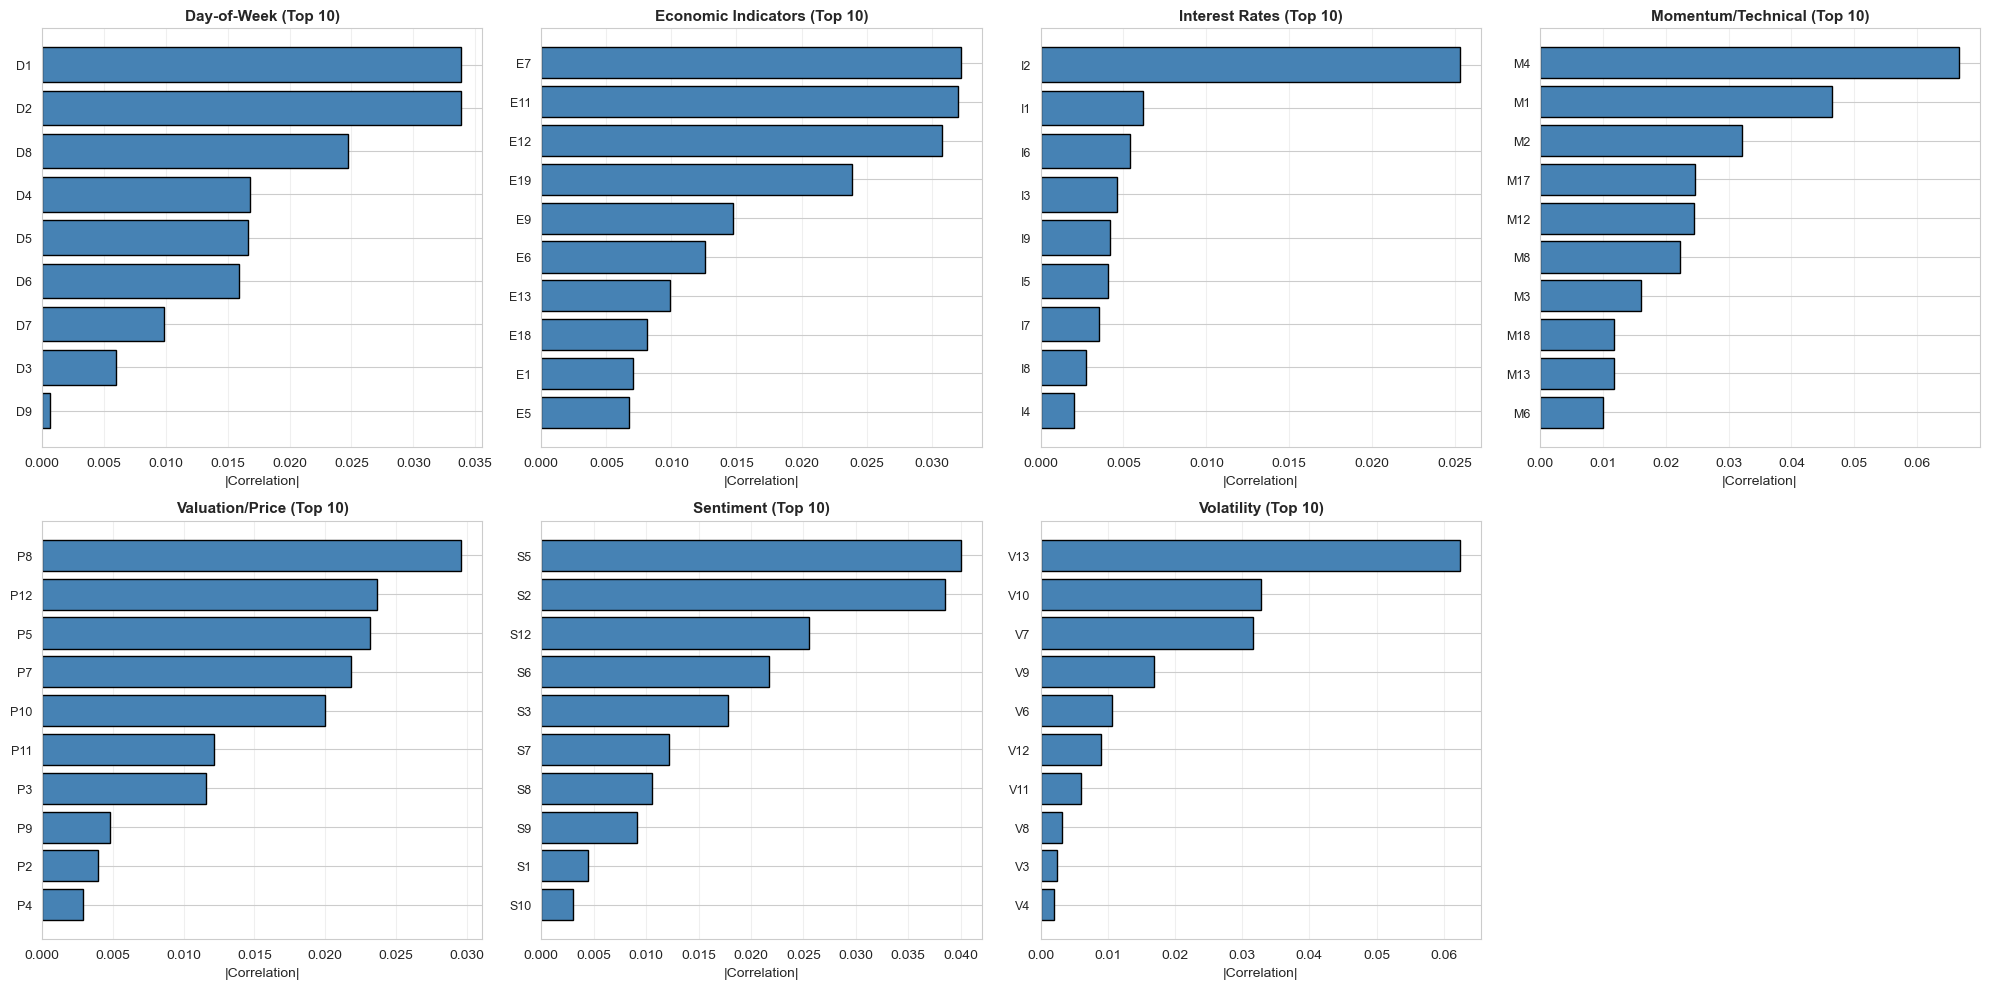


📊 Feature Family Summary:
Family                    Count    Mean |Corr|     Max |Corr|      Top Feature         
Day-of-Week               9        0.017583        0.033882        D1                  
Economic Indicators       20       0.010679        0.032230        E7                  
Interest Rates            9        0.006442        0.025281        I2                  
Momentum/Technical        18       0.017098        0.066632        M4                  
Valuation/Price           13       0.012122        0.029628        P8                  
Sentiment                 12       0.015415        0.040009        S5                  
Volatility                13       0.013930        0.062378        V13                 


📊 Missing Values by Family:
Family                    Avg Missing %   Max Missing %   Worst Feature       
Day-of-Week               0.00%           0.00%           D1                  
Economic Indicators       15.18%           77.02%           E7                  


In [4]:
# === 3. FEATURE FAMILY ANALYSIS ===
print("\n" + "="*70)
print(" 3. FEATURE FAMILIES & CORRELATIONS")
print("="*70 + "\n")

# Group features by family
families = {}
for col in train.columns:
    if col[0] in 'MEIPVSD':
        fam = col[0]
        families.setdefault(fam, []).append(col)

family_names = {
    'M': 'Momentum/Technical',
    'E': 'Economic Indicators',
    'I': 'Interest Rates',
    'P': 'Valuation/Price',
    'V': 'Volatility',
    'S': 'Sentiment',
    'D': 'Day-of-Week'
}

# Calculate correlations with target
target = train["market_forward_excess_returns"]
family_corrs = {}

for fam_key, cols in families.items():
    corrs = train[cols].corrwith(target).abs().sort_values(ascending=False)
    family_corrs[fam_key] = corrs

# Plotting
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (fam_key, corrs) in enumerate(sorted(family_corrs.items())):
    top_10 = corrs.head(10)
    
    axes[idx].barh(range(len(top_10)), top_10.values, color='steelblue', edgecolor='black')
    axes[idx].set_yticks(range(len(top_10)))
    axes[idx].set_yticklabels(top_10.index, fontsize=9)
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('|Correlation|')
    axes[idx].set_title(f'{family_names.get(fam_key, fam_key)} (Top 10)', fontsize=11, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='x')

# Hide the last subplot if odd number
if len(family_corrs) < 8:
    axes[7].axis('off')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Feature Family Summary:")
print(f"{'Family':<25} {'Count':<8} {'Mean |Corr|':<15} {'Max |Corr|':<15} {'Top Feature':<20}")
print("="*90)
for fam_key in sorted(families.keys()):
    cols = families[fam_key]
    corrs = family_corrs[fam_key]
    print(f"{family_names.get(fam_key, fam_key):<25} {len(cols):<8} {corrs.mean():.6f}        {corrs.max():.6f}        {corrs.idxmax():<20}")

# Missing values by family
print("\n\n📊 Missing Values by Family:")
print(f"{'Family':<25} {'Avg Missing %':<15} {'Max Missing %':<15} {'Worst Feature':<20}")
print("="*90)
for fam_key in sorted(families.keys()):
    cols = families[fam_key]
    missing_pct = train[cols].isna().mean() * 100
    print(f"{family_names.get(fam_key, fam_key):<25} {missing_pct.mean():.2f}%           {missing_pct.max():.2f}%           {missing_pct.idxmax():<20}")


 4. CORRELATION ANALYSIS



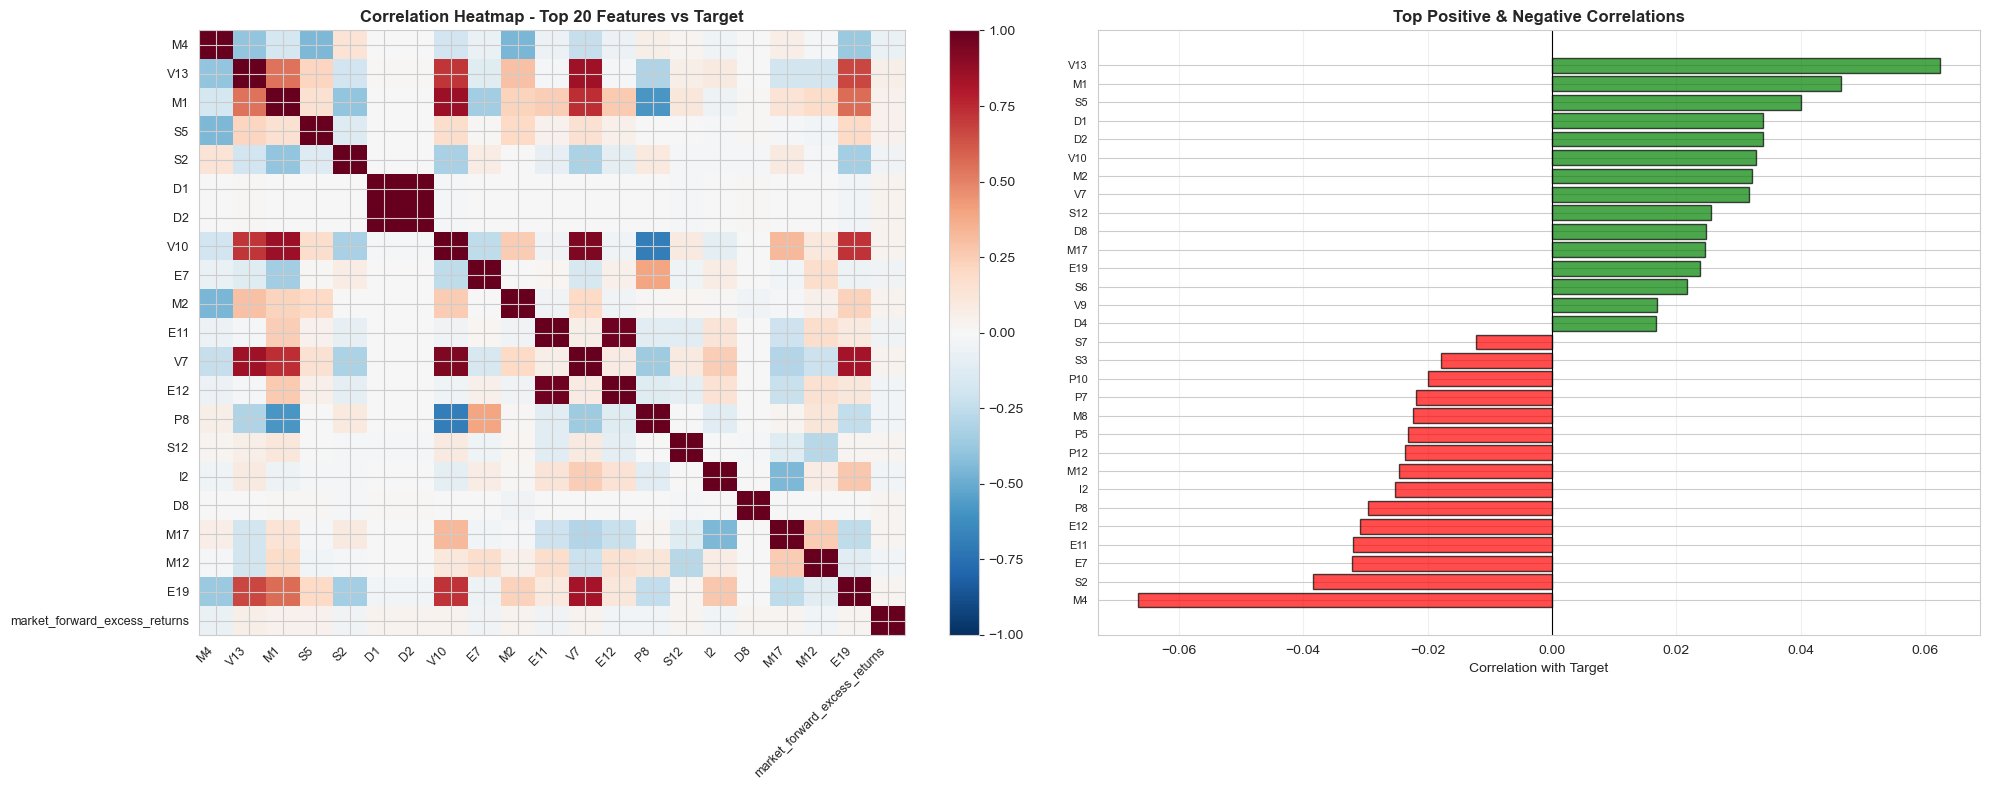


📊 Top 10 Positive Correlations:
M4     0.066632
V13    0.062378
M1     0.046433
S5     0.040009
S2     0.038493
D1     0.033882
D2     0.033882
V10    0.032859
E7     0.032230
M2     0.032166
dtype: float64

📊 Top 10 Negative Correlations:
M4    -0.066632
S2    -0.038493
E7    -0.032230
E11   -0.032007
E12   -0.030813
P8    -0.029628
I2    -0.025281
M12   -0.024569
P12   -0.023641
P5    -0.023136
dtype: float64


⚠️ Multicollinearity Check (Top 20 Features):
   Found 9 highly correlated pairs (|r| > 0.7):
      D1              ↔ D2              : 1.0000
      E11             ↔ E12             : 0.9744
      V10             ↔ V7              : 0.9342
      M1              ↔ V10             : 0.8567
      V13             ↔ V7              : 0.8471
      V7              ↔ E19             : 0.8302
      M1              ↔ V7              : 0.7383
      V10             ↔ E19             : 0.7215
      V13             ↔ V10             : 0.7172


In [5]:
# === 4. CORRELATION HEATMAPS ===
print("\n" + "="*70)
print(" 4. CORRELATION ANALYSIS")
print("="*70 + "\n")

# Select top features by absolute correlation with target
target = train["market_forward_excess_returns"]
all_features = [col for col in train.columns if col[0] in 'MEIPVSD']
feature_corrs = train[all_features].corrwith(target).abs().sort_values(ascending=False)

# Top 20 features
top_20_features = feature_corrs.head(20).index.tolist()
top_20_features_with_target = top_20_features + ["market_forward_excess_returns"]

# Calculate correlation matrix
corr_matrix_top20 = train[top_20_features_with_target].corr()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 4.1 Heatmap of top 20 features
im1 = axes[0].imshow(corr_matrix_top20, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(top_20_features_with_target)))
axes[0].set_yticks(range(len(top_20_features_with_target)))
axes[0].set_xticklabels(top_20_features_with_target, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(top_20_features_with_target, fontsize=9)
axes[0].set_title('Correlation Heatmap - Top 20 Features vs Target', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# 4.2 Correlation with target (bar chart)
target_corr_sorted = train[all_features].corrwith(target).sort_values()
top_neg = target_corr_sorted.head(15)
top_pos = target_corr_sorted.tail(15)
top_combined = pd.concat([top_neg, top_pos])

colors = ['red' if x < 0 else 'green' for x in top_combined.values]
axes[1].barh(range(len(top_combined)), top_combined.values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_combined)))
axes[1].set_yticklabels(top_combined.index, fontsize=8)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Correlation with Target')
axes[1].set_title('Top Positive & Negative Correlations', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print top correlations
print("\n📊 Top 10 Positive Correlations:")
print(feature_corrs.head(10))

print("\n📊 Top 10 Negative Correlations:")
negative_corrs = train[all_features].corrwith(target).sort_values()
print(negative_corrs.head(10))

# Multicollinearity check (within top features)
print("\n\n⚠️ Multicollinearity Check (Top 20 Features):")
high_corr_pairs = []
for i in range(len(top_20_features)):
    for j in range(i+1, len(top_20_features)):
        corr_val = corr_matrix_top20.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((top_20_features[i], top_20_features[j], corr_val))

if high_corr_pairs:
    print(f"   Found {len(high_corr_pairs)} highly correlated pairs (|r| > 0.7):")
    for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"      {feat1:<15} ↔ {feat2:<15} : {corr_val:.4f}")
else:
    print("   ✓ No high multicollinearity detected (|r| > 0.7)")


 5. CRISIS PERIODS & EXTREME EVENTS DETECTION



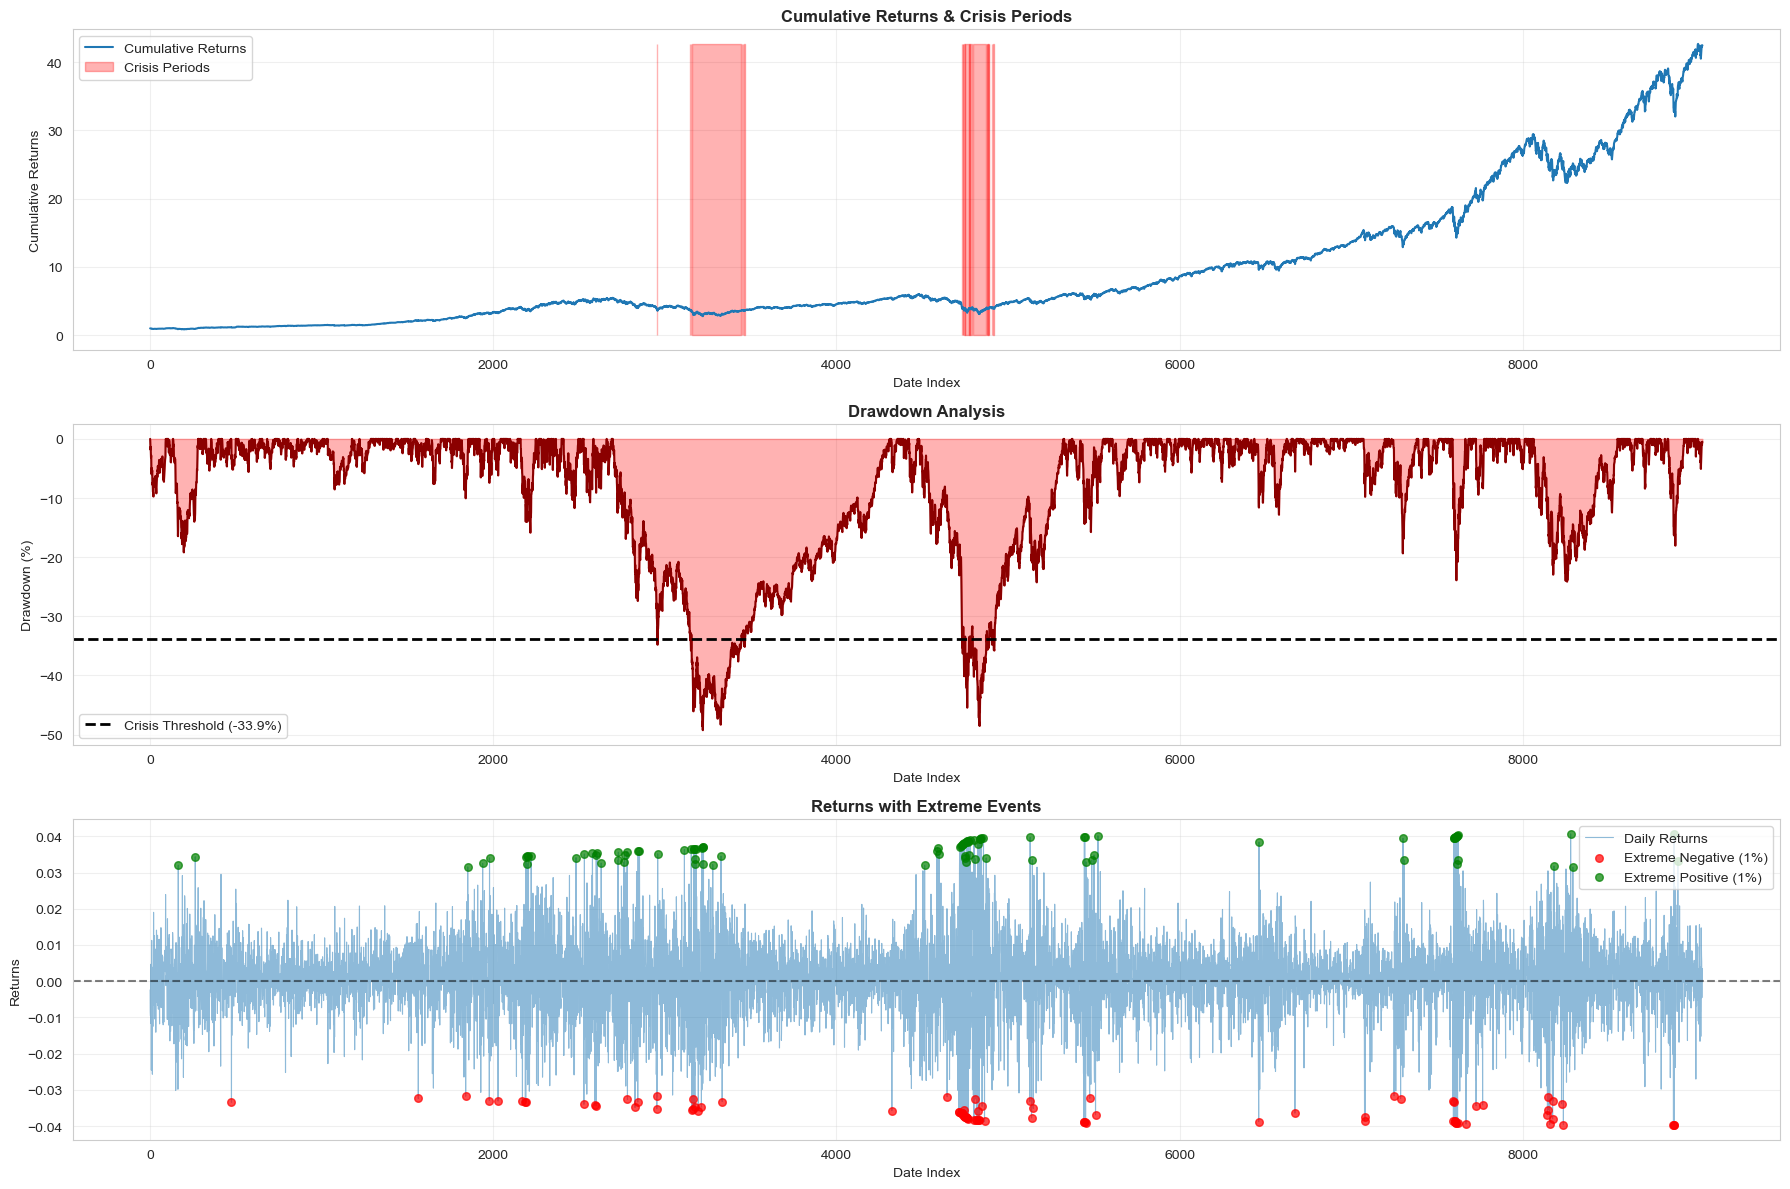


📊 Crisis Period Statistics:

   Crisis Periods:
      Count:         453 days (5.0%)
      Mean Return:   -30.33% (annualized)
      Volatility:    28.53% (annualized)
      Sharpe:        -1.0631
      Max Drawdown:  -49.24%

   Normal Periods:
      Count:         8595 days (95.0%)
      Mean Return:   2.97% (annualized)
      Volatility:    15.89% (annualized)
      Sharpe:        0.1868


📊 High Volatility Period Statistics:

   High Volatility (Top 10%):
      Count:         899 days
      Avg Vol:       0.30%
      Mean Return:   8.70% (annualized)
      Sharpe:        0.3018

   Normal Volatility:
      Count:         8149 days
      Avg Vol:       0.14%
      Mean Return:   0.48% (annualized)
      Sharpe:        0.0326


📊 Extreme Events:
   Extreme Negative Days: 91 (threshold: -0.0316)
   Extreme Positive Days: 91 (threshold: 0.0315)
   Largest Loss:  -0.0398 (date_id: 8883)
   Largest Gain:  0.0407 (date_id: 8882)


In [6]:
# === 5. CRISIS PERIODS & MARKET EVENTS ===
print("\n" + "="*70)
print(" 5. CRISIS PERIODS & EXTREME EVENTS DETECTION")
print("="*70 + "\n")

# Calculate rolling metrics
fwd_ret = train["forward_returns"]
cumulative = (1 + fwd_ret).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max
vol_63 = fwd_ret.rolling(63).std() * np.sqrt(252)

# Identify crisis periods (large drawdowns)
crisis_threshold = drawdown.quantile(0.05)  # Bottom 5% drawdowns
crisis_periods = drawdown < crisis_threshold

# Identify high volatility periods
high_vol_threshold = vol_63.quantile(0.90)  # Top 10% volatility
high_vol_periods = vol_63 > high_vol_threshold

# Extreme return days
extreme_neg_threshold = fwd_ret.quantile(0.01)  # Bottom 1%
extreme_pos_threshold = fwd_ret.quantile(0.99)  # Top 1%

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

# 5.1 Cumulative returns with crisis periods highlighted
axes[0].plot(cumulative.values, linewidth=1.5, label='Cumulative Returns')
axes[0].fill_between(range(len(crisis_periods)), 0, cumulative.max(), 
                     where=crisis_periods, alpha=0.3, color='red', label='Crisis Periods')
axes[0].set_title('Cumulative Returns & Crisis Periods', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date Index')
axes[0].set_ylabel('Cumulative Returns')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 5.2 Drawdown with crisis threshold
axes[1].fill_between(range(len(drawdown)), drawdown.values*100, 0, alpha=0.3, color='red')
axes[1].plot(drawdown.values*100, color='darkred', linewidth=1.5)
axes[1].axhline(y=crisis_threshold*100, color='black', linestyle='--', linewidth=2, 
               label=f'Crisis Threshold ({crisis_threshold*100:.1f}%)')
axes[1].set_title('Drawdown Analysis', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date Index')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 5.3 Returns with extreme events highlighted
axes[2].plot(fwd_ret.values, alpha=0.5, linewidth=0.8, label='Daily Returns')
axes[2].scatter(np.where(fwd_ret < extreme_neg_threshold)[0], 
               fwd_ret[fwd_ret < extreme_neg_threshold].values,
               color='red', s=30, alpha=0.7, label='Extreme Negative (1%)', zorder=3)
axes[2].scatter(np.where(fwd_ret > extreme_pos_threshold)[0], 
               fwd_ret[fwd_ret > extreme_pos_threshold].values,
               color='green', s=30, alpha=0.7, label='Extreme Positive (1%)', zorder=3)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_title('Returns with Extreme Events', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Date Index')
axes[2].set_ylabel('Returns')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics during crisis periods
print("\n📊 Crisis Period Statistics:")
crisis_returns = train.loc[crisis_periods, "market_forward_excess_returns"]
normal_returns = train.loc[~crisis_periods, "market_forward_excess_returns"]

print(f"\n   Crisis Periods:")
print(f"      Count:         {crisis_periods.sum()} days ({crisis_periods.sum()/len(train)*100:.1f}%)")
print(f"      Mean Return:   {crisis_returns.mean()*252*100:.2f}% (annualized)")
print(f"      Volatility:    {crisis_returns.std()*np.sqrt(252)*100:.2f}% (annualized)")
print(f"      Sharpe:        {(crisis_returns.mean()/crisis_returns.std()*np.sqrt(252)):.4f}")
print(f"      Max Drawdown:  {drawdown[crisis_periods].min()*100:.2f}%")

print(f"\n   Normal Periods:")
print(f"      Count:         {(~crisis_periods).sum()} days ({(~crisis_periods).sum()/len(train)*100:.1f}%)")
print(f"      Mean Return:   {normal_returns.mean()*252*100:.2f}% (annualized)")
print(f"      Volatility:    {normal_returns.std()*np.sqrt(252)*100:.2f}% (annualized)")
print(f"      Sharpe:        {(normal_returns.mean()/normal_returns.std()*np.sqrt(252)):.4f}")

# High volatility period statistics
print("\n\n📊 High Volatility Period Statistics:")
high_vol_returns = train.loc[high_vol_periods, "market_forward_excess_returns"]
low_vol_returns = train.loc[~high_vol_periods, "market_forward_excess_returns"]

print(f"\n   High Volatility (Top 10%):")
print(f"      Count:         {high_vol_periods.sum()} days")
print(f"      Avg Vol:       {vol_63[high_vol_periods].mean():.2f}%")
print(f"      Mean Return:   {high_vol_returns.mean()*252*100:.2f}% (annualized)")
print(f"      Sharpe:        {(high_vol_returns.mean()/high_vol_returns.std()*np.sqrt(252)):.4f}")

print(f"\n   Normal Volatility:")
print(f"      Count:         {(~high_vol_periods).sum()} days")
print(f"      Avg Vol:       {vol_63[~high_vol_periods].mean():.2f}%")
print(f"      Mean Return:   {low_vol_returns.mean()*252*100:.2f}% (annualized)")
print(f"      Sharpe:        {(low_vol_returns.mean()/low_vol_returns.std()*np.sqrt(252)):.4f}")

# Extreme events
print("\n\n📊 Extreme Events:")
print(f"   Extreme Negative Days: {(fwd_ret < extreme_neg_threshold).sum()} (threshold: {extreme_neg_threshold:.4f})")
print(f"   Extreme Positive Days: {(fwd_ret > extreme_pos_threshold).sum()} (threshold: {extreme_pos_threshold:.4f})")
print(f"   Largest Loss:  {fwd_ret.min():.4f} (date_id: {train.loc[fwd_ret.idxmin(), 'date_id']})")
print(f"   Largest Gain:  {fwd_ret.max():.4f} (date_id: {train.loc[fwd_ret.idxmax(), 'date_id']})")


 6. MISSING DATA ANALYSIS



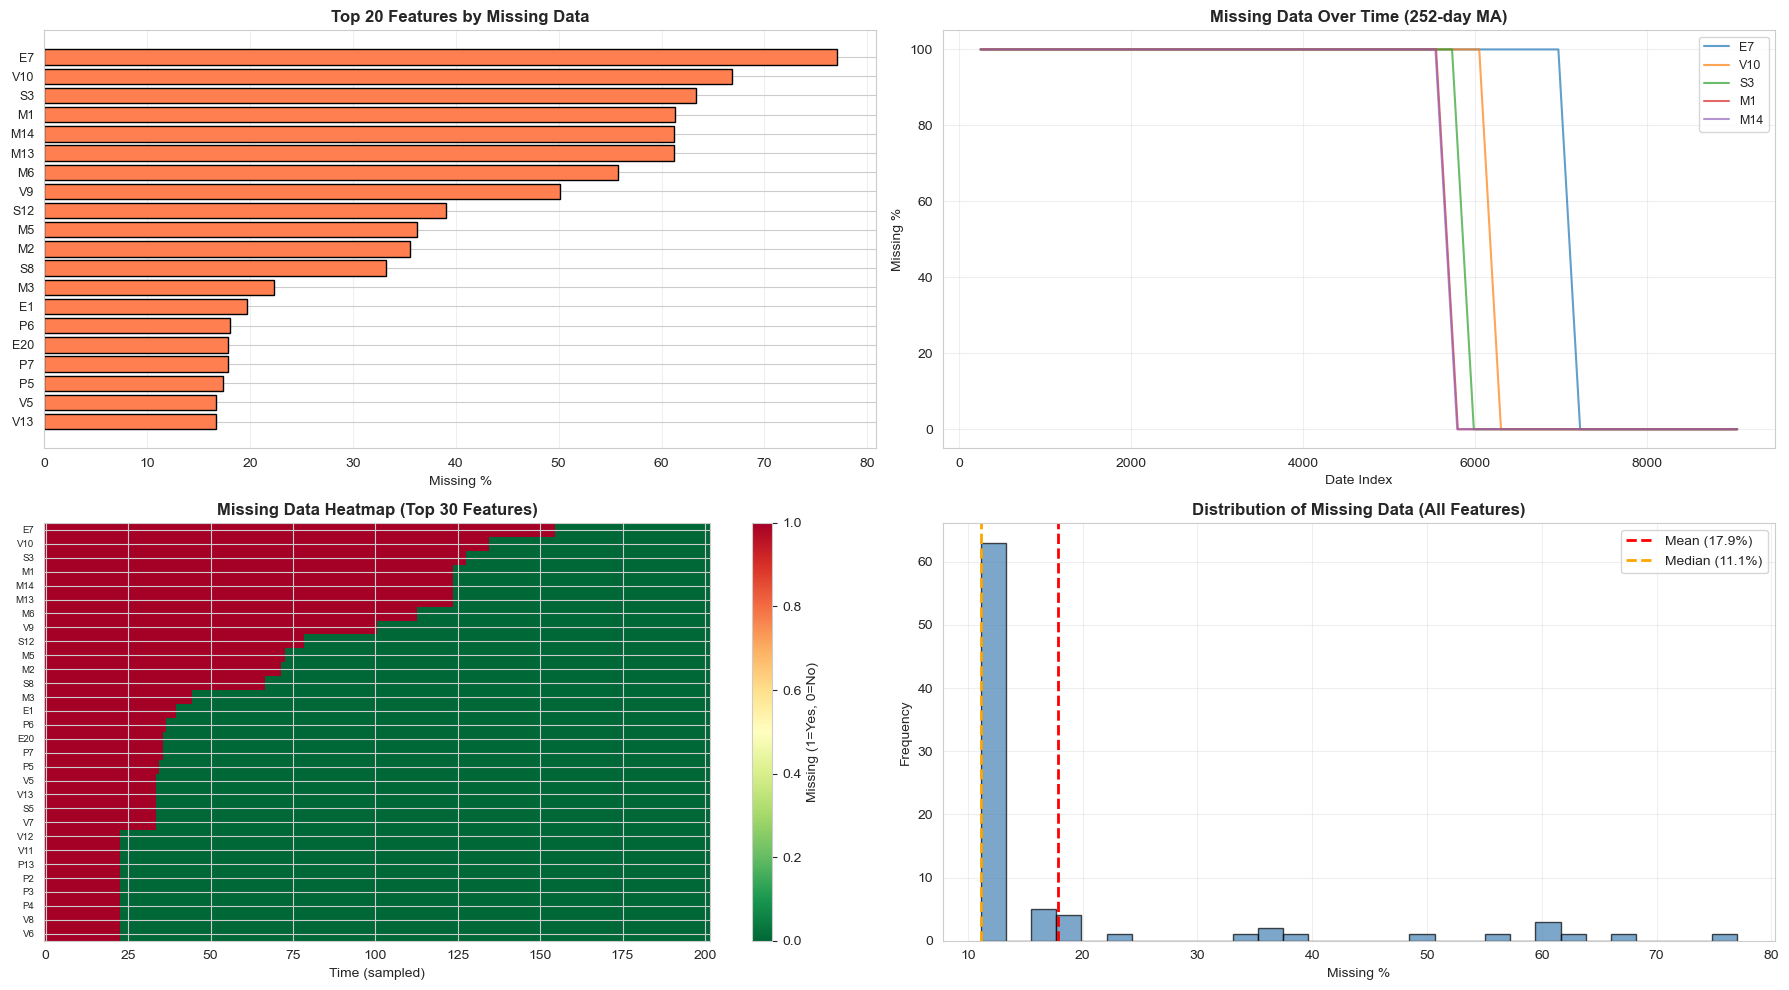


📊 Missing Data Summary:
   Total features:                  98
   Features with missing values:    85
   Features with >50% missing:      8
   Features with >20% missing:      13
   Average missing % (all features): 17.90%
   Max missing %:                   77.02% (E7)


📊 Top 10 Features with Most Missing Data:
    1. E7                    77.02%
    2. V10                   66.85%
    3. S3                    63.36%
    4. M1                    61.31%
    5. M14                   61.23%
    6. M13                   61.23%
    7. M6                    55.74%
    8. V9                    50.17%
    9. S12                   39.09%
   10. M5                    36.28%


In [7]:
# === 6. MISSING DATA PATTERNS ===
print("\n" + "="*70)
print(" 6. MISSING DATA ANALYSIS")
print("="*70 + "\n")

# Calculate missing percentages
missing_pct = train.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 6.1 Top features with missing values
top_missing = missing_pct.head(20)
axes[0, 0].barh(range(len(top_missing)), top_missing.values, color='coral', edgecolor='black')
axes[0, 0].set_yticks(range(len(top_missing)))
axes[0, 0].set_yticklabels(top_missing.index, fontsize=9)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('Missing %')
axes[0, 0].set_title('Top 20 Features by Missing Data', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# 6.2 Missing data over time (for top missing features)
top_5_missing_features = missing_pct.head(5).index.tolist()
for feat in top_5_missing_features:
    missing_series = train[feat].isna().astype(int)
    axes[0, 1].plot(missing_series.rolling(252).mean() * 100, label=feat, linewidth=1.5, alpha=0.7)
axes[0, 1].set_title('Missing Data Over Time (252-day MA)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Date Index')
axes[0, 1].set_ylabel('Missing %')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# 6.3 Missing data heatmap (sample of features)
sample_features = missing_pct.head(30).index.tolist()
missing_matrix = train[sample_features].isna().astype(int)
# Downsample for visualization
step = max(1, len(missing_matrix) // 200)
missing_matrix_sample = missing_matrix.iloc[::step, :]

im = axes[1, 0].imshow(missing_matrix_sample.T, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
axes[1, 0].set_yticks(range(len(sample_features)))
axes[1, 0].set_yticklabels(sample_features, fontsize=7)
axes[1, 0].set_xlabel('Time (sampled)')
axes[1, 0].set_title('Missing Data Heatmap (Top 30 Features)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1, 0], label='Missing (1=Yes, 0=No)')

# 6.4 Distribution of missing percentages
axes[1, 1].hist(missing_pct, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=missing_pct.mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean ({missing_pct.mean():.1f}%)')
axes[1, 1].axvline(x=missing_pct.median(), color='orange', linestyle='--', linewidth=2, 
                  label=f'Median ({missing_pct.median():.1f}%)')
axes[1, 1].set_xlabel('Missing %')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Missing Data (All Features)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n📊 Missing Data Summary:")
print(f"   Total features:                  {len(train.columns)}")
print(f"   Features with missing values:    {len(missing_pct)}")
print(f"   Features with >50% missing:      {(missing_pct > 50).sum()}")
print(f"   Features with >20% missing:      {(missing_pct > 20).sum()}")
print(f"   Average missing % (all features): {missing_pct.mean():.2f}%")
print(f"   Max missing %:                   {missing_pct.max():.2f}% ({missing_pct.idxmax()})")

print("\n\n📊 Top 10 Features with Most Missing Data:")
for idx, (feat, pct) in enumerate(missing_pct.head(10).items(), 1):
    print(f"   {idx:2}. {feat:<20} {pct:6.2f}%")


 7. FEATURE IMPORTANCE (QUICK MODEL)

Training LightGBM model for feature importance...


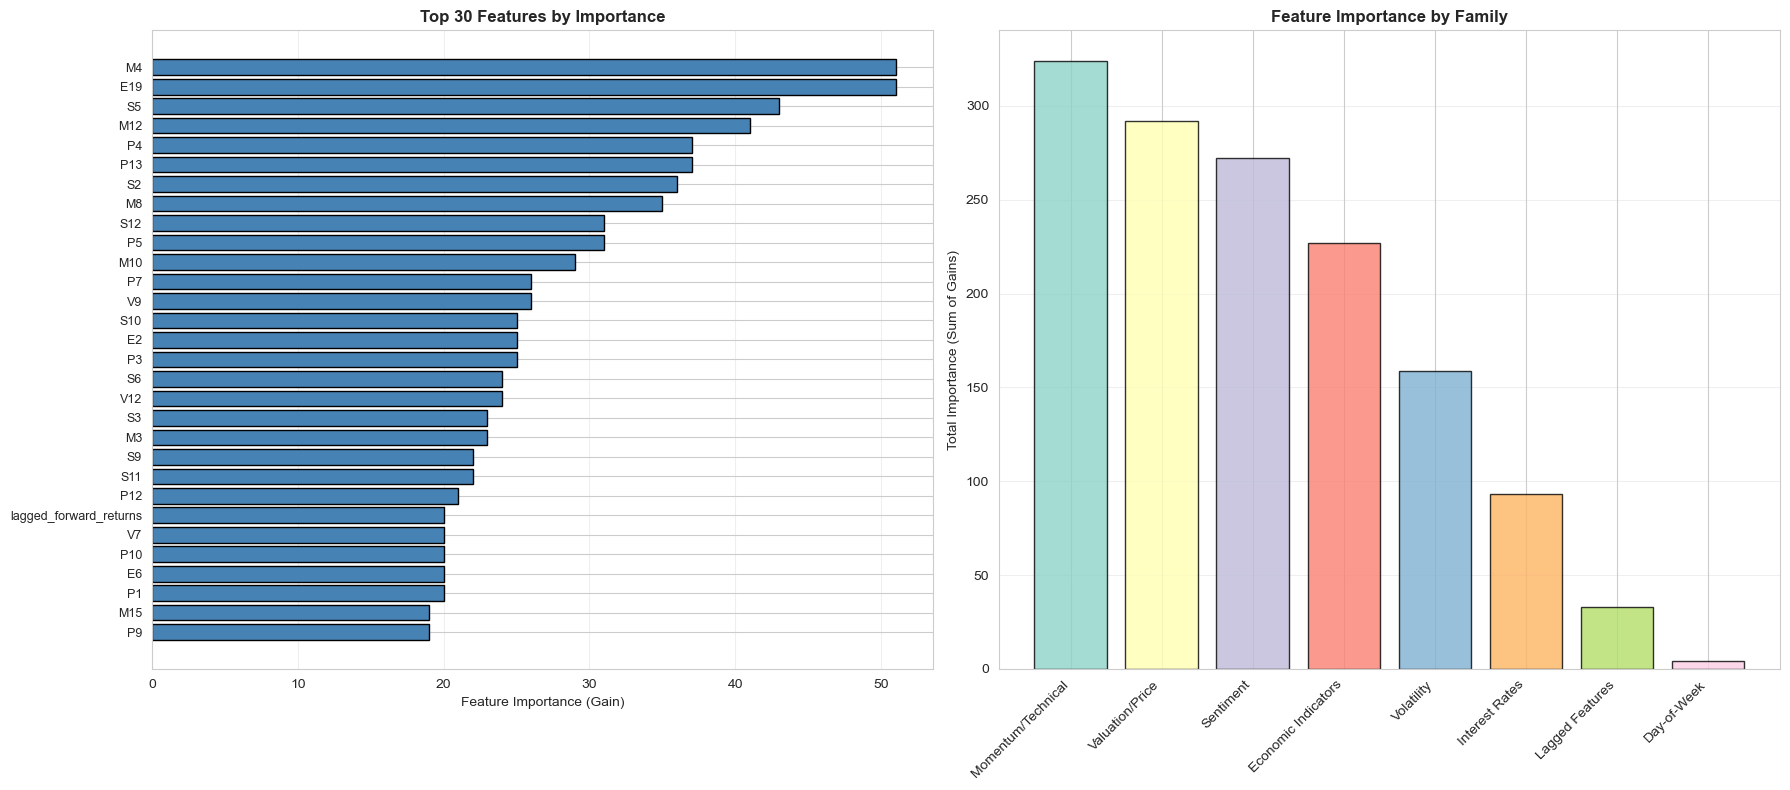


📊 Top 20 Most Important Features:
   M4                                       51.00
   E19                                      51.00
   S5                                       43.00
   M12                                      41.00
   P4                                       37.00
   P13                                      37.00
   S2                                       36.00
   M8                                       35.00
   S12                                      31.00
   P5                                       31.00
   M10                                      29.00
   P7                                       26.00
   V9                                       26.00
   S10                                      25.00
   E2                                       25.00
   P3                                       25.00
   S6                                       24.00
   V12                                      24.00
   S3                                       23.00
   M3          

In [8]:
# === 7. FEATURE IMPORTANCE PREVIEW ===
print("\n" + "="*70)
print(" 7. FEATURE IMPORTANCE (QUICK MODEL)")
print("="*70 + "\n")

from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

# Prepare data (last 5 years for speed)
last_5y = train["date_id"].max() - (252 * 5)
train_5y = train[train["date_id"] >= last_5y].copy()

# Create lagged features
train_5y["lagged_forward_returns"] = train_5y["forward_returns"].shift(1)
train_5y["lagged_risk_free_rate"] = train_5y["risk_free_rate"].shift(1)
train_5y["lagged_market_forward_excess_returns"] = train_5y["market_forward_excess_returns"].shift(1)

# Feature columns
feature_cols = [col for col in train_5y.columns if col[0] in 'MEIPVSD' or col.startswith('lagged')]
target_col = "market_forward_excess_returns"

# Drop NaNs
X = train_5y[feature_cols].fillna(method='ffill').fillna(0)
y = train_5y[target_col]
valid_idx = ~y.isna()
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train simple model
print("Training LightGBM model for feature importance...")
model = LGBMRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 7.1 Top 30 features by importance
top_30 = importance_df.head(30)
axes[0].barh(range(len(top_30)), top_30['importance'].values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_30)))
axes[0].set_yticklabels(top_30['feature'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Feature Importance (Gain)')
axes[0].set_title('Top 30 Features by Importance', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# 7.2 Importance by family
importance_by_family = {}
for idx, row in importance_df.iterrows():
    feat = row['feature']
    imp = row['importance']
    
    if feat.startswith('lagged'):
        fam = 'Lagged'
    elif feat[0] in 'MEIPVSD':
        fam = feat[0]
    else:
        fam = 'Other'
    
    importance_by_family[fam] = importance_by_family.get(fam, 0) + imp

family_importance_df = pd.DataFrame({
    'family': list(importance_by_family.keys()),
    'total_importance': list(importance_by_family.values())
}).sort_values('total_importance', ascending=False)

family_names_map = {
    'M': 'Momentum/Technical',
    'E': 'Economic Indicators',
    'I': 'Interest Rates',
    'P': 'Valuation/Price',
    'V': 'Volatility',
    'S': 'Sentiment',
    'D': 'Day-of-Week',
    'Lagged': 'Lagged Features'
}

family_labels = [family_names_map.get(f, f) for f in family_importance_df['family']]
colors_fam = plt.cm.Set3(range(len(family_importance_df)))

axes[1].bar(range(len(family_importance_df)), family_importance_df['total_importance'].values, 
           color=colors_fam, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(family_importance_df)))
axes[1].set_xticklabels(family_labels, rotation=45, ha='right', fontsize=10)
axes[1].set_ylabel('Total Importance (Sum of Gains)')
axes[1].set_title('Feature Importance by Family', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print top features
print("\n📊 Top 20 Most Important Features:")
for idx, row in importance_df.head(20).iterrows():
    print(f"   {row['feature']:<35} {row['importance']:>10.2f}")

print("\n\n📊 Feature Importance by Family:")
for idx, row in family_importance_df.iterrows():
    fam_name = family_names_map.get(row['family'], row['family'])
    print(f"   {fam_name:<30} {row['total_importance']:>10.2f}")

# Model performance
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n\n📊 Quick Model Performance (Test Set):")
print(f"   MSE:  {mse:.8f}")
print(f"   RMSE: {np.sqrt(mse):.8f}")
print(f"   R²:   {r2:.6f}")

print("\n" + "="*70)
print(" EDA COMPLETE - Ready for modeling!")
print("="*70)